# Testing the Waveform Generator

This noteboook will serve as a quick way of testing if the WaveformModule for 1PAT1R is consistently passing what it should be to the amplitude, summation and trajectory modules.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from few.waveform import Waveform1PAT1R, FastKerrEccentricEquatorialFlux

In [2]:
# --- Define Parameters ---
m1 = 1e6       # primary mass [solar masses]
m2 = 10      # secondary mass [solar masses]
chi1  = 1e-5
a = chi1 # primary spin chi1 (dimensionless)
p0 = 9.0      # initial orbital separation [M]
theta = np.pi / 3.0   # polar viewing angle [rad]
phi   = 0.0           # azimuthal viewing angle [rad]
chi2  = 0.1 # secondary spin

dt = 5.   # time step [s]
T  = 1    # total duration [yr]

In [3]:

# --- Generate waveform ---
WF1PAT1R = Waveform1PAT1R()
h1PAT1R = WF1PAT1R(m1, m2, a, p0, theta, phi, chi2, dt=dt, T=T)

h1PAT1Rzeropaamps = WF1PAT1R(m1, m2, a, p0, theta, phi, chi2, dt=dt, T=T, zero_PA_amps_only=True)
h1PAT1Rnoprimary = WF1PAT1R(m1, m2, a, p0, theta, phi, chi2, dt=dt, T=T, evolve_primary=False)


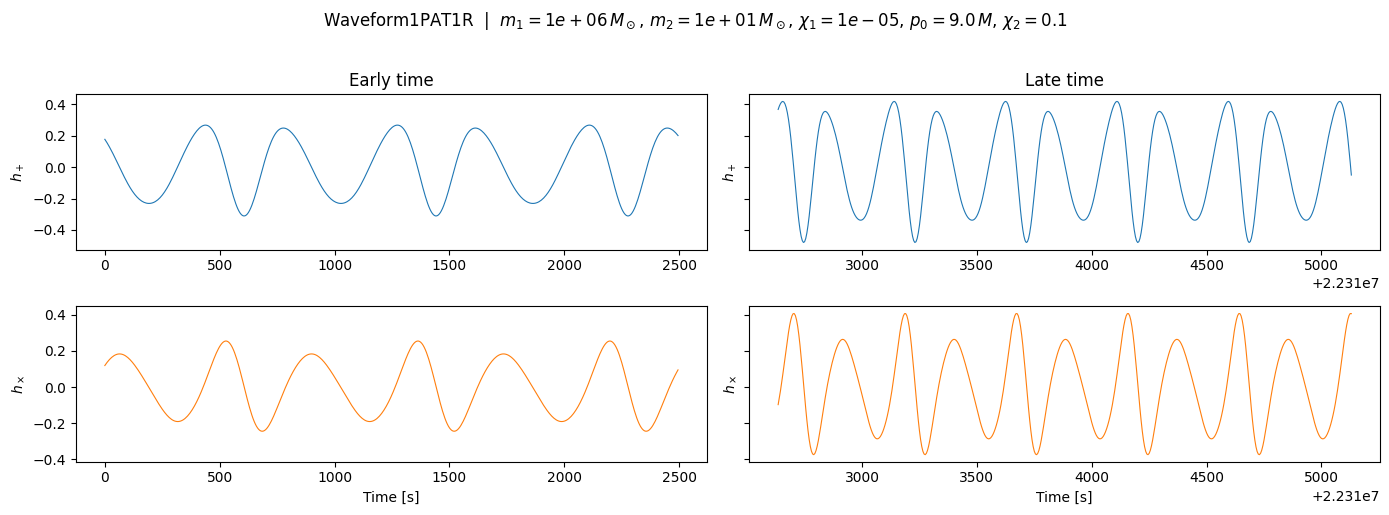

In [4]:
t1PA = np.arange(len(h1PAT1R)) * dt  # time array in seconds

# Number of cycles to show at each end
n_show = 500

# --- Plot: early vs late time ---
fig, axes = plt.subplots(2, 2, figsize=(14, 5), sharey='row')

title = (
    rf"Waveform1PAT1R  |  $m_1={m1:.0e}\,M_\odot$, $m_2={m2:.0e}\,M_\odot$, "
    rf"$\chi_1={a}$, $p_0={p0}\,M$, $\chi_2={chi2}$"
)

for col, (slc, label) in enumerate([
    (slice(None, n_show),  "Early time"),
    (slice(-n_show, None), "Late time"),
]):
    axes[0, col].plot(t1PA[slc], h1PAT1R.real[slc], lw=0.8)
    axes[0, col].set_title(label)
    axes[0, col].set_ylabel(r"$h_+$")

    axes[1, col].plot(t1PA[slc], -h1PAT1R.imag[slc], lw=0.8, color="C1")
    axes[1, col].set_ylabel(r"$h_\times$")
    axes[1, col].set_xlabel("Time [s]")

fig.suptitle(title, y=1.02)
plt.tight_layout()
plt.show()


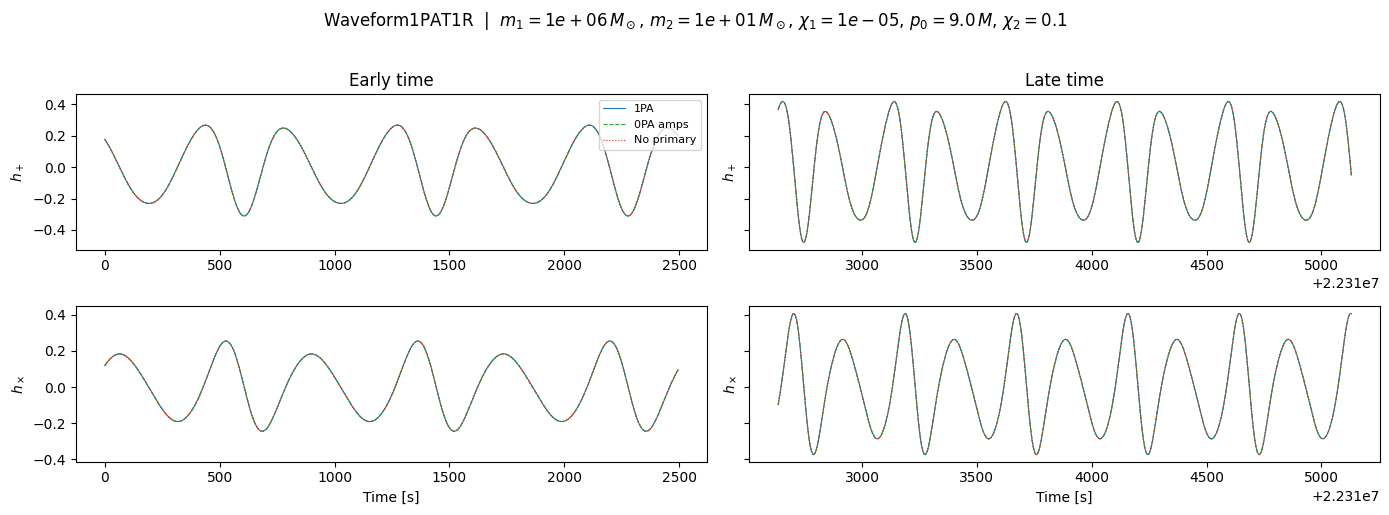

In [5]:
t1PA = np.arange(len(h1PAT1R)) * dt  # time array in seconds

# Number of cycles to show at each end
n_show = 500

# --- Plot: early vs late time ---
fig, axes = plt.subplots(2, 2, figsize=(14, 5), sharey='row')

title = (
    rf"Waveform1PAT1R  |  $m_1={m1:.0e}\,M_\odot$, $m_2={m2:.0e}\,M_\odot$, "
    rf"$\chi_1={a}$, $p_0={p0}\,M$, $\chi_2={chi2}$"
)

for col, (slc, label) in enumerate([
    (slice(None, n_show),  "Early time"),
    (slice(-n_show, None), "Late time"),
]):
    axes[0, col].plot(t1PA[slc], h1PAT1R.real[slc],             lw=0.8, color="C0", label="1PA")
    axes[0, col].plot(t1PA[slc], h1PAT1Rzeropaamps.real[slc],   lw=0.8, color="C2", label="0PA amps", ls="--")
    axes[0, col].plot(t1PA[slc], h1PAT1Rnoprimary.real[slc],    lw=0.8, color="C3", label="No primary", ls=":")
    axes[0, col].set_title(label)
    axes[0, col].set_ylabel(r"$h_+$")

    axes[1, col].plot(t1PA[slc], -h1PAT1R.imag[slc],            lw=0.8, color="C0", label="1PA")
    axes[1, col].plot(t1PA[slc], -h1PAT1Rzeropaamps.imag[slc],  lw=0.8, color="C2", label="0PA amps", ls="--")
    axes[1, col].plot(t1PA[slc], -h1PAT1Rnoprimary.imag[slc],   lw=0.8, color="C3", label="No primary", ls=":")
    axes[1, col].set_ylabel(r"$h_\times$")
    axes[1, col].set_xlabel("Time [s]")

# Add legend once, on the top-left panel
axes[0, 0].legend(fontsize=8, loc="upper right")

fig.suptitle(title, y=1.02)
plt.tight_layout()
plt.show()

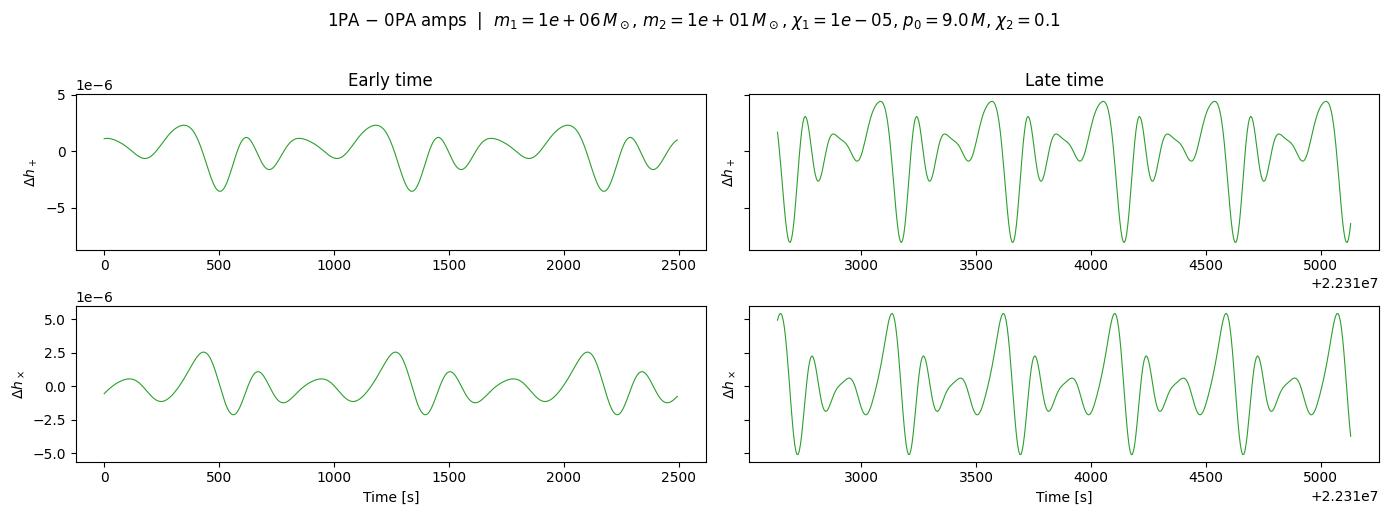

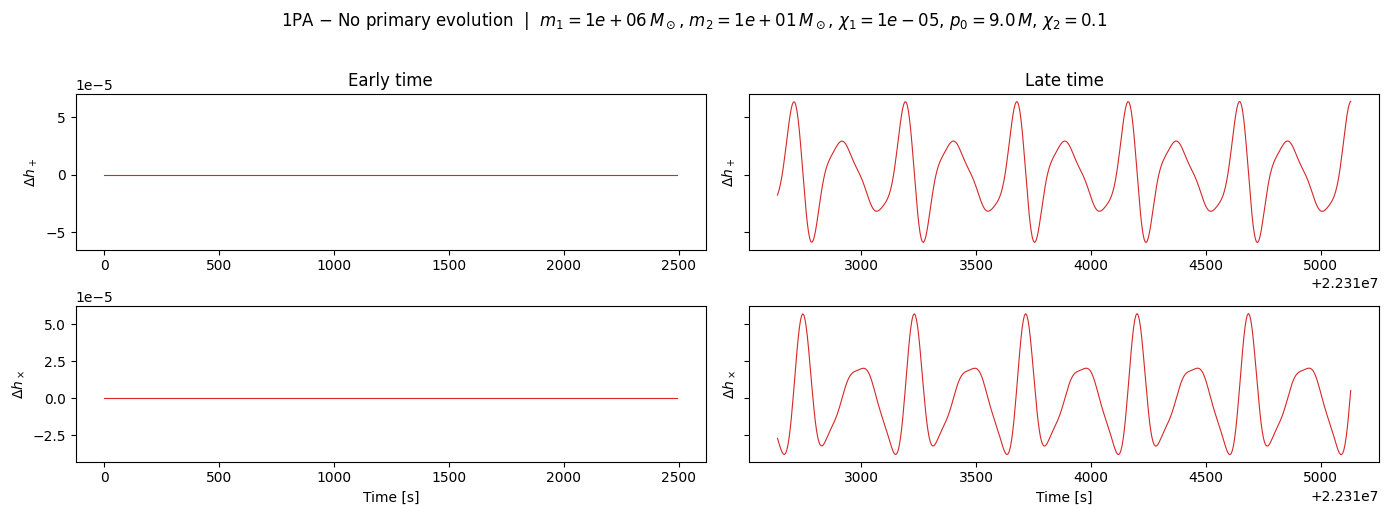

In [6]:
diffs = [
    (h1PAT1R - h1PAT1Rzeropaamps,  "1PA $-$ 0PA amps",          "C2"),
    (h1PAT1R - h1PAT1Rnoprimary,   "1PA $-$ No primary evolution", "C3"),
]

for diff, diff_label, color in diffs:
    fig, axes = plt.subplots(2, 2, figsize=(14, 5), sharey='row')

    title = (
        rf"{diff_label}  |  $m_1={m1:.0e}\,M_\odot$, $m_2={m2:.0e}\,M_\odot$, "
        rf"$\chi_1={a}$, $p_0={p0}\,M$, $\chi_2={chi2}$"
    )

    for col, (slc, label) in enumerate([
        (slice(None, n_show),  "Early time"),
        (slice(-n_show, None), "Late time"),
    ]):
        axes[0, col].plot(t1PA[slc], diff.real[slc],  lw=0.8, color=color)
        axes[0, col].set_title(label)
        axes[0, col].set_ylabel(r"$\Delta h_+$")

        axes[1, col].plot(t1PA[slc], -diff.imag[slc], lw=0.8, color=color)
        axes[1, col].set_ylabel(r"$\Delta h_\times$")
        axes[1, col].set_xlabel("Time [s]")

    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

In [5]:
# --- Generate comparison waveform ---
WFKerr0PA = FastKerrEccentricEquatorialFlux()
hKerr = WFKerr0PA(m1, m2, a, p0, 0, 1,theta, phi, dt=dt, T=T)

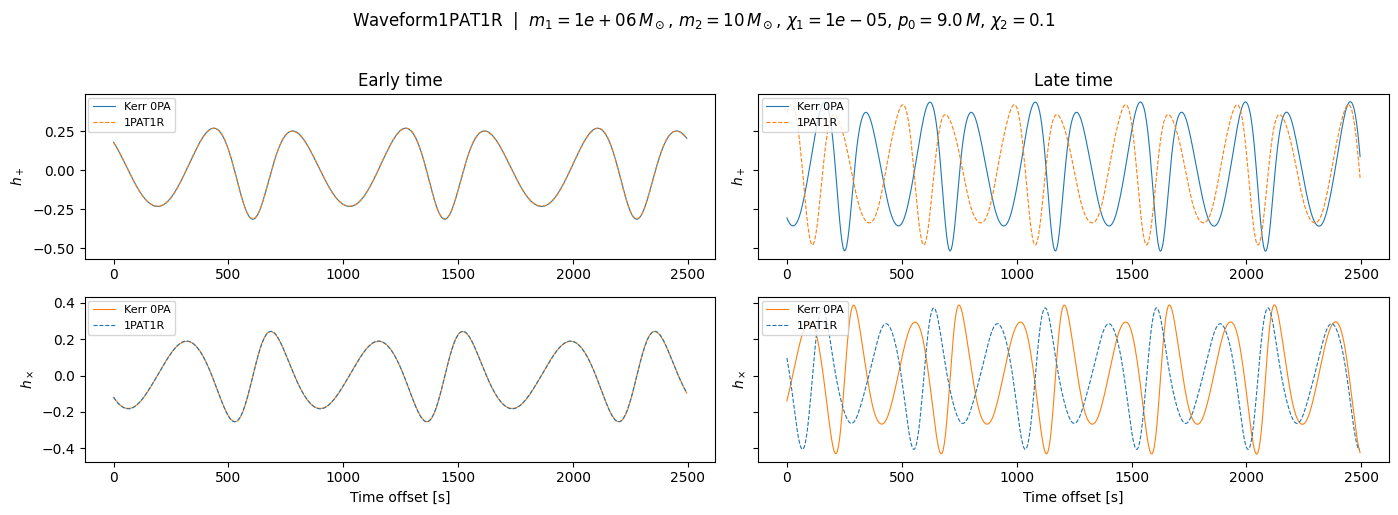

In [6]:
tKerr = np.arange(len(hKerr)) * dt  # time array in seconds

# Number of samples to show at each end
n_show = 500

# --- Plot: early vs late time ---
fig, axes = plt.subplots(2, 2, figsize=(14, 5), sharey='row')

title = (
    rf"Waveform1PAT1R  |  $m_1={m1:.0e}\,M_\odot$, $m_2={m2}\,M_\odot$, "
    rf"$\chi_1={a}$, $p_0={p0}\,M$, $\chi_2={chi2}$"
)

for col, (label, slc_kerr, slc_1pa) in enumerate([
    ("Early time", slice(None, n_show),  slice(None, n_show)),
    ("Late time",  slice(-n_show, None), slice(-n_show, None)),
]):
    tK = tKerr[slc_kerr];  tK = tK - tK[0]
    t1 = t1PA[slc_1pa];    t1 = t1 - t1[0]

    axes[0, col].plot(tK, hKerr.real[slc_kerr], lw=0.8, label="Kerr 0PA")
    axes[0, col].plot(t1, h1PAT1R.real[slc_1pa], lw=0.8, ls="--", color="C1", label="1PAT1R")
    axes[0, col].set_title(label)
    axes[0, col].set_ylabel(r"$h_+$")
    axes[0, col].legend(fontsize=8, loc="upper left", bbox_to_anchor=(0, 1),
                        borderaxespad=0.3)

    axes[1, col].plot(tK, hKerr.imag[slc_kerr], lw=0.8, color="C1", label="Kerr 0PA")
    axes[1, col].plot(t1, h1PAT1R.imag[slc_1pa], lw=0.8, ls="--", color="C0", label="1PAT1R")
    axes[1, col].set_ylabel(r"$h_\times$")
    axes[1, col].set_xlabel("Time offset [s]")
    axes[1, col].legend(fontsize=8, loc="upper left", bbox_to_anchor=(0, 1),
                        borderaxespad=0.3)

fig.suptitle(title, y=1.02)
plt.tight_layout()
plt.show()


In [7]:
from few.trajectory.ode.IPAT1R import Trajectory1PAT1R

In [8]:
# --- Define Parameters ---
m1 = 1e6       # primary mass [solar masses]
m2 = 10      # secondary mass [solar masses]
a  = 0.0       # primary spin chi1 (dimensionless)
p0 = 9.5      # initial orbital separation [M]
theta = np.pi / 3.0   # polar viewing angle [rad]
phi   = 0.0           # azimuthal viewing angle [rad]
chi2  = 0.0           # secondary spin

dt = 5.   # time step [s]
T  = 1    # total duration [yr]

In [9]:
from few.trajectory.inspiral import EMRIInspiral

# Note that for this test, I commented out all the 1PA order terms in Trajectory1PAT1R, 
# so this should be equivalent to a 0PA trajectory with the same parameters.
traj1PA = EMRIInspiral(func=Trajectory1PAT1R)

# EMRIInspiral expects: (m1, m2, a, p0, e0, xI, *extra_args, T=, dt=)
#   a    = chi1 (primary spin)
#   e0   = 0.0  (circular)
#   xI   = 1.0  (equatorial prograde)
#   chi2 = first extra arg -> additional_args[0] in Trajectory1PAT1R
t, p, e, xI_traj, Phi_phi, Phi_theta, Phi_r, dM, dchi1 = traj1PA(
    m1, m2,
    a,        # chi1 (primary spin)
    p0,
    0.0,      # e0: circular
    1.0,      # xI: equatorial prograde
    chi2,     # extra arg -> additional_args[0]
    T=T
)

print(f"Trajectory length: {len(t)} points")
print(f"p: {p[0]:.4f} -> {p[-1]:.4f} M")
print(f"Phi_phi: {Phi_phi[0]:.4f} -> {Phi_phi[-1]:.4f} rad")


Trajectory length: 26 points
p: 9.5000 -> 6.6517 M
Phi_phi: 0.0000 -> 262673.3794 rad


In [10]:
from few.trajectory.ode.flux import KerrEccEqFlux

In [11]:
traj0PA = EMRIInspiral(func=KerrEccEqFlux)


t2, p2, e2, xI_traj, Phi_phi2, Phi_theta2, Phi_r2 = traj0PA(
    m1, m2,
    a,        # chi1 (primary spin)
    p0,
    0.0,      # e0: circular
    1.0,      # xI: equatorial prograde
    T=T,
)

print(f"Trajectory length: {len(t2)} points")
print(f"p: {p2[0]:.4f} -> {p2[-1]:.4f} M")
print(f"Phi_phi: {Phi_phi2[0]:.4f} -> {Phi_phi2[-1]:.4f} rad")

Trajectory length: 26 points
p: 9.5000 -> 6.6514 M
Phi_phi: 0.0000 -> 262674.9311 rad


In [12]:
t[-1]

np.float64(31558149.76354559)

Trajectory length: 26 points
p: 9.5000 -> 6.6517 M
Phi_phi: 0.0000 -> 262673.3794 rad


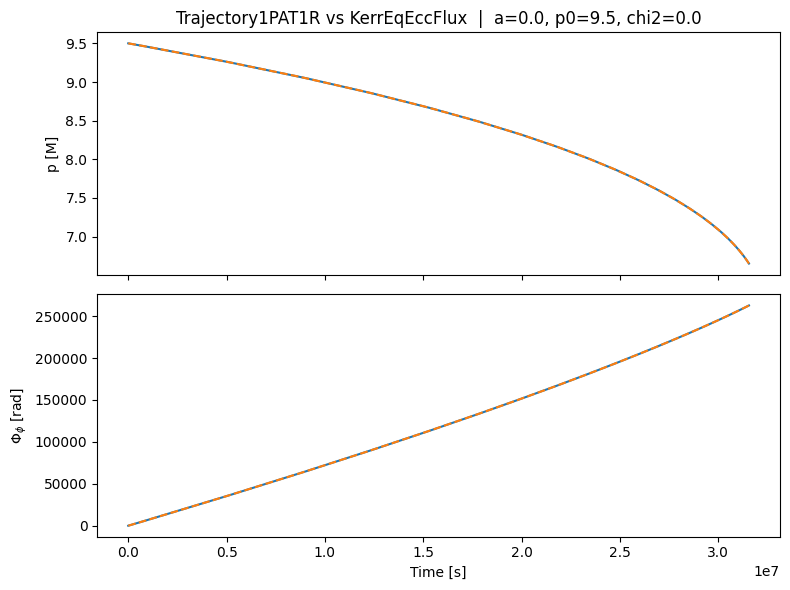

In [13]:
print(f"Trajectory length: {len(t)} points")
print(f"p: {p[0]:.4f} -> {p[-1]:.4f} M")
print(f"Phi_phi: {Phi_phi[0]:.4f} -> {Phi_phi[-1]:.4f} rad")

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axes[0].plot(t, p)
axes[0].plot(t2, p2, linestyle="--")
axes[0].set_ylabel("p [M]")
axes[0].set_title(f"Trajectory1PAT1R vs KerrEqEccFlux  |  a={a}, p0={p0}, chi2={chi2}")
axes[1].plot(t, Phi_phi)
axes[1].plot(t2, Phi_phi2,linestyle="--")
axes[1].set_ylabel(r"$\Phi_\phi$ [rad]")
axes[1].set_xlabel("Time [s]")
plt.tight_layout()
plt.show()


In [14]:
from scipy.interpolate import CubicSpline
pSpline = CubicSpline(t2, p2)
p2Resampled = pSpline(t)


Phi_phiSpline = CubicSpline(t2, Phi_phi2)
Phi_phi2Resampled = Phi_phiSpline(t)


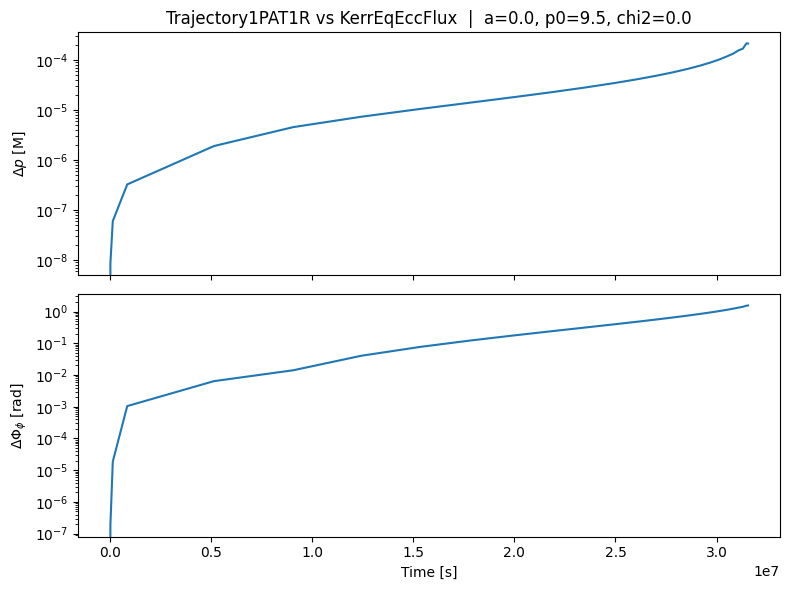

In [15]:

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axes[0].plot(t, abs(p2Resampled-p))
axes[0].set_ylabel(r"$ \Delta p$ [M]")
axes[0].set_yscale("log")
axes[0].set_title(f"Trajectory1PAT1R vs KerrEqEccFlux  |  a={a}, p0={p0}, chi2={chi2}")
axes[1].plot(t, abs(Phi_phi2Resampled-Phi_phi))
axes[1].set_yscale("log")
axes[1].set_ylabel(r"$ \Delta \Phi_\phi$ [rad]")
axes[1].set_xlabel("Time [s]")
plt.tight_layout()
plt.show()

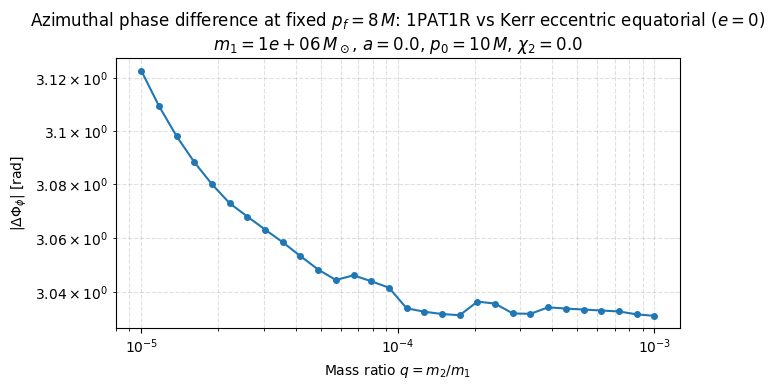

In [16]:
# --- Phase difference vs mass ratio ---
# Compare the azimuthal phase accumulated between Trajectory1PAT1R (1PA)
# and KerrEccEqFlux (0PA) at a fixed final semi-latus rectum p_final.

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.optimize import brentq

# --- Parameters ---
m1      = 1e6
a       = 0.0
p0      = 10
p_final = 8
chi2    = 0.0
Tmax    = 10.0   # long enough to reach p_final

traj1PA  = EMRIInspiral(func=Trajectory1PAT1R)
traj0PA  = EMRIInspiral(func=KerrEccEqFlux)

q_values = np.logspace(-5, -3, 30)
m2_values = q_values * m1

delta_Phi_phi = np.zeros(len(q_values))
delta_Phi_phi[:] = np.nan   # mark failures

for i, (q, m2) in enumerate(zip(q_values, m2_values)):

    # Integrate both inspirals
    t1, p1_, e1_, xI1_, Phi_phi_1PA, *_ = traj1PA(
        m1, m2, a, p0, 0.0, 1.0, chi2, T=Tmax
    )
    t0, p0_, e0_, xI0_, Phi_phi_0PA, *_ = traj0PA(
        m1, m2, a, p0, 0.0, 1.0, T=Tmax
    )

    # Check if p_final is reached
    if not ((p1_[0] - p_final) * (p1_[-1] - p_final) < 0):
        print(f"1PA: q={q:.2e} did not reach p_final={p_final}")
        continue

    if not ((p0_[0] - p_final) * (p0_[-1] - p_final) < 0):
        print(f"0PA: q={q:.2e} did not reach p_final={p_final}")
        continue

    # Build splines
    cs_p1   = CubicSpline(t1, p1_)
    cs_phi1 = CubicSpline(t1, Phi_phi_1PA)

    cs_p0   = CubicSpline(t0, p0_)
    cs_phi0 = CubicSpline(t0, Phi_phi_0PA)

    # Solve p(t) = p_final
    t1_f = brentq(lambda tt: cs_p1(tt) - p_final, t1[0], t1[-1])
    t0_f = brentq(lambda tt: cs_p0(tt) - p_final, t0[0], t0[-1])

    # Evaluate phases
    Phi1_f = cs_phi1(t1_f)
    Phi0_f = cs_phi0(t0_f)

    delta_Phi_phi[i] = abs(Phi1_f - Phi0_f)

# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(q_values, delta_Phi_phi, marker='o', ms=4, lw=1.5)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'Mass ratio $q = m_2 / m_1$')
ax.set_ylabel(r'$|\Delta\Phi_\phi|$ [rad]')
ax.set_title(
    rf'Azimuthal phase difference at fixed $p_f={p_final}\,M$: '
    '1PAT1R vs Kerr eccentric equatorial ($e=0$)'
    '\n'
    rf'$m_1={m1:.0e}\,M_\odot$, $a={a}$, $p_0={p0}\,M$, $\chi_2={chi2}$'
)
ax.grid(True, which='both', ls='--', alpha=0.4)
plt.tight_layout()
plt.show()


Clearly a 1PA phase error.

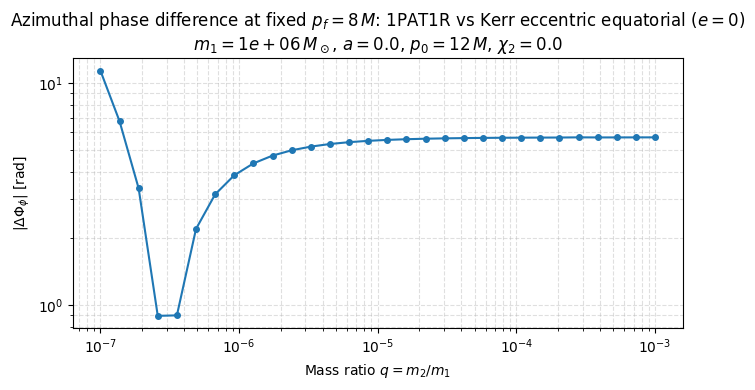

In [17]:
# --- Phase difference vs mass ratio ---
# Compare the azimuthal phase accumulated between Trajectory1PAT1R (1PA)
# and KerrEccEqFlux (0PA) at a fixed final semi-latus rectum p_final.

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.optimize import brentq

# --- Parameters ---
m1      = 1e6
a       = 0.0
p0      = 12
p_final = 8
chi2    = 0.0
Tmax    = 400.0   # long enough to reach p_final

traj1PA  = EMRIInspiral(func=Trajectory1PAT1R)
traj0PA  = EMRIInspiral(func=KerrEccEqFlux)

q_values = np.logspace(-7, -3, 30)
m2_values = q_values * m1

delta_Phi_phi = np.zeros(len(q_values))
delta_Phi_phi[:] = np.nan   # mark failures

for i, (q, m2) in enumerate(zip(q_values, m2_values)):

    # Integrate both inspirals
    t1, p1_, e1_, xI1_, Phi_phi_1PA, *_ = traj1PA(
        m1, m2, a, p0, 0.0, 1.0, chi2, T=Tmax
    )
    t0, p0_, e0_, xI0_, Phi_phi_0PA, *_ = traj0PA(
        m1, m2, a, p0, 0.0, 1.0, T=Tmax
    )

    # Check if p_final is reached
    if not ((p1_[0] - p_final) * (p1_[-1] - p_final) < 0):
        print(f"1PA: q={q:.2e} did not reach p_final={p_final}")
        continue

    if not ((p0_[0] - p_final) * (p0_[-1] - p_final) < 0):
        print(f"0PA: q={q:.2e} did not reach p_final={p_final}")
        continue

    # Build splines
    cs_p1   = CubicSpline(t1, p1_)
    cs_phi1 = CubicSpline(t1, Phi_phi_1PA)

    cs_p0   = CubicSpline(t0, p0_)
    cs_phi0 = CubicSpline(t0, Phi_phi_0PA)

    # Solve p(t) = p_final
    t1_f = brentq(lambda tt: cs_p1(tt) - p_final, t1[0], t1[-1])
    t0_f = brentq(lambda tt: cs_p0(tt) - p_final, t0[0], t0[-1])

    # Evaluate phases
    Phi1_f = cs_phi1(t1_f)
    Phi0_f = cs_phi0(t0_f)

    delta_Phi_phi[i] = abs(Phi1_f - Phi0_f)

# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(q_values, delta_Phi_phi, marker='o', ms=4, lw=1.5)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'Mass ratio $q = m_2 / m_1$')
ax.set_ylabel(r'$|\Delta\Phi_\phi|$ [rad]')
ax.set_title(
    rf'Azimuthal phase difference at fixed $p_f={p_final}\,M$: '
    '1PAT1R vs Kerr eccentric equatorial ($e=0$)'
    '\n'
    rf'$m_1={m1:.0e}\,M_\odot$, $a={a}$, $p_0={p0}\,M$, $\chi_2={chi2}$'
)
ax.grid(True, which='both', ls='--', alpha=0.4)
plt.tight_layout()
plt.show()
